In [189]:
import os
import re
import pickle as pkl
import ast
from collections import Counter
from typing import List, Tuple, Any
from tqdm import tqdm
import time

import pandas as pd
import numpy as np
import calibration as cal

import torch

from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [190]:
from llm_unsupervised_conf.metrics import *
from llm_unsupervised_conf.math_utils import stack_embeddings
from llm_unsupervised_conf.calibration import fit_predict_prob_models
from llm_unsupervised_conf.plots import plot_reliability, plot_avg_and_worstcase_by_method, plot_method_comparisons, METHODS_MAP_SHORT, METHODS_MAP, DATASETS_MAP

In [191]:
from llm_unsupervised_conf.utils import maybe_add_verbal_conf_row, load_out_df, set_seed

In [192]:
def compute_consistency_from_df(df: pd.DataFrame) -> pd.Series:
    """
    train_df: columns ["id", "answer"], many rows per id.
    returns Series indexed by id: max frequency / count
    """
    counts = df.groupby("id")["answer"].value_counts(dropna=False)
    top = counts.groupby(level=0).max()
    denom = df.groupby("id")["answer"].size()
    return (top / denom).sort_index()


def metric_row(name, scores, correct, n_bins):
    return [
        name,
        get_ece1(scores, correct, n_bins=n_bins),
        get_ece2(scores, correct, n_bins=n_bins),
        get_mce(scores, correct, n_bins=n_bins),
        get_nll(scores, correct),
        brier_score_loss(correct, scores),
        roc_auc_score(correct, scores),
    ]


def run_exp(
    dataset,
    model,
    n=1000,
    k_train=100,
    temp_train=0.7,
    temp_test=0.6,
    prob_models=("ridge_clip",),   # <-- pass a list/tuple of the methods above
    include_verbal_conf=True,
    random_state=42,
    n_bins=12,
    embedding_text="question_response",
    drop_bad_rows=True,
    test_prop=0.6,
    verbose=False,
    include_alt_ablation=True,
    include_question_ablation=True,
    k_sample=20
):
    """
    prob_models controls which embedding->prob models to include.
    Example:
      prob_models=["ridge_clip","ridge_logit","hgb_logit","mlp_logit","isotonic_on_ridge"]
    """

    set_seed(random_state)

    model_name = model.split("/")[-1]

    try:
        out_df, df_save_path = load_out_df(
            dataset, 
            model_name, 
            n, 
            temp_train=0.7, 
            k_train=100, 
            temp_test=temp_test, 
            embedding_text=embedding_text, 
            drop_bad_rows=drop_bad_rows
        )
    except:
        return None

    slim_df_path = f"../outputs/{model_name}/{dataset}/n_{n}_temp_{temp_train}_k_{k_train}_SLIM_train_df.pkl"
    # print("loading", slim_df_path)
    with open(slim_df_path, "rb") as f:
        slim_df = pkl.load(f)

    sampled = slim_df.groupby("id", group_keys=False).sample(n=k_sample, random_state=random_state)
    out_df["ablate_consistency"] = out_df["id"].map(compute_consistency_from_df(sampled))

    # print(metric_row("sc scores", out_df["ablate_consistency"], out_df["correct"], n_bins))

    # --------------------
    # Split
    # --------------------
    train_df, test_df = train_test_split(
        out_df,
        test_size=test_prop,
        random_state=random_state,
        shuffle=True,
    )

    X_train = stack_embeddings(train_df, "embeddings")
    # if k_sample == k_train:
    #     y_train = train_df["consistency"].astype(np.float32).to_numpy()  # target in [0,1]
    # else:
    y_train = train_df["ablate_consistency"].astype(np.float32).to_numpy()  # target in [0,1]

    X_test = stack_embeddings(test_df, "embeddings")

    # These are for evaluation
    con_scores = test_df["consistency"].to_numpy(dtype=float)
    correct = test_df["correct"].to_numpy(dtype=int)

    logprobs = test_df["avg_logprobs"].to_numpy(dtype=float)
    ans_logprobs = test_df["ans_logprobs"].to_numpy(dtype=float)
    lp = np.exp(logprobs)
    alp = np.exp(ans_logprobs)

    if verbose:
        print(f"Results: (accuracy={correct.mean():.4f})")

    ########################
    # Baselines
    ########################
    score_sources = {
        "logprob": lp,
        "ans_logprob": alp,
        "oracle_sc": con_scores,
    }
    
    rows = [metric_row(name, scores, correct, n_bins) for name, scores in score_sources.items()]

    ########################
    # Ours
    ########################
    prob_models = list(prob_models) if prob_models is not None else []
    preds = fit_predict_prob_models(
        X_train=X_train,
        y_train_prob=y_train,
        X_test=X_test,
        methods=prob_models,
        random_state=random_state,
    )

    for method_name, pred_probs in preds.items():
        rows.append(metric_row(method_name, pred_probs, correct, n_bins))

    # --------------------
    # Pack + display
    # --------------------
    exp_df = pd.DataFrame(rows, columns=["Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC"])
    exp_df["Model"] = model
    exp_df["Dataset"] = dataset
    exp_df["Accuracy"] = float(correct.mean())
    exp_df = exp_df[["Model", "Dataset", "Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC", "Accuracy"]]

    return exp_df


In [193]:
def run_all_exps(
    models, 
    datasets, 
    exp_key=None, 
    n_trials=10, 
    n_bins=12, 
    test_prop=0.6,
    embedding_text="question_response",
    prob_models = ["ridge_clip","split_isotonic_on_ridge","split_isotonic_on_ridge_nrt"],
    k_sample = 20
):

    exp_pairs = [
        [0.5, 20],
        [0.7, 100],
        [0.9, 20]
    ]

    full_df = []
    for dataset in datasets:
        print(f"[status] running {dataset}")
        start_time = time.time()
        for model in models:
            print(f"[status] running {model}")
            for temp_train, k_train in exp_pairs:
            
                for seed in range(n_trials):
                    df = run_exp(
                        dataset=dataset,
                        model=model,
                        random_state=seed,
                        k_train=k_train,
                        temp_train=temp_train,
                        n_bins=n_bins,
                        test_prop=test_prop,
                        embedding_text=embedding_text,
                        prob_models=prob_models,
                        k_sample=k_sample
                    )
                    if df is None:
                        continue
                    df["seed"] = seed
                    df["k_sample"] = k_sample
                    df["k_train"] = k_train
                    df["temp_train"] = temp_train
                    full_df.append(df)

                
        print("--- %s seconds ---" % (time.time() - start_time))
    
    full_df = pd.concat(full_df)


    display(full_df.head(5))

    full_df.to_csv("../results/temp_ablation_results.csv", index=False)

    return full_df



In [181]:
models = [
    "Qwen/Qwen3-1.7B", 
    "Qwen/Qwen3-4B-Thinking-2507", 
]
datasets = [
    "gsm8k",
    "polymath",
    "trivia_qa",
    "sciq",
    "webq"
]

exp_key = "ablate_temp"
n_trials = 50

full_df = run_all_exps(models, datasets, exp_key, n_trials)

[status] running gsm8k
[status] running Qwen/Qwen3-1.7B
[status] running Qwen/Qwen3-4B-Thinking-2507
--- 80.872811794281 seconds ---
[status] running polymath
[status] running Qwen/Qwen3-1.7B
[status] running Qwen/Qwen3-4B-Thinking-2507
--- 90.85885047912598 seconds ---
[status] running trivia_qa
[status] running Qwen/Qwen3-1.7B
[status] running Qwen/Qwen3-4B-Thinking-2507
--- 97.66423201560974 seconds ---
[status] running sciq
[status] running Qwen/Qwen3-1.7B
[status] running Qwen/Qwen3-4B-Thinking-2507
--- 82.37023663520813 seconds ---
[status] running webq
[status] running Qwen/Qwen3-1.7B
[status] running Qwen/Qwen3-4B-Thinking-2507
--- 87.3473699092865 seconds ---


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy,seed,k_sample,k_train,temp_train
0,Qwen/Qwen3-1.7B,gsm8k,logprob,0.033963,0.042120,0.080217,0.300298,0.082599,0.679425,0.906667,0,20,20,0.5
1,Qwen/Qwen3-1.7B,gsm8k,ans_logprob,0.089557,0.089557,0.089557,1.135165,0.091642,0.610590,0.906667,0,20,20,0.5
2,Qwen/Qwen3-1.7B,gsm8k,oracle_sc,0.056967,0.067996,0.180000,0.565186,0.069481,0.767053,0.906667,0,20,20,0.5
3,Qwen/Qwen3-1.7B,gsm8k,ridge_clip,0.038128,0.043827,0.083473,0.445659,0.077404,0.715533,0.906667,0,20,20,0.5
4,Qwen/Qwen3-1.7B,gsm8k,split_isotonic_on_ridge,0.055960,0.061187,0.106818,0.338489,0.080982,0.706046,0.906667,0,20,20,0.5


In [194]:
full_df = pd.read_csv("../results/temp_ablation_results.csv")

In [195]:
def plot_metric_vs_temperature(
    full_df: pd.DataFrame,
    target_metric: str,
    method: str = "split_isotonic_on_ridge_nrt",
    baseline_method: str = "logprob",
    dataset_col: str = "Dataset",
    temp_col: str = "temp_train",
    method_col: str = "Method",
    figsize_per_panel=(4.3, 4.0),
    agg: str = "mean",              # "mean" or "median"
    show_errorbars: bool = True,
    err_type: str = "sem",          # "std", "sem", or None
    sharey: bool = True,
    rotate_xticks: int = 0,
    plt_save_path: str = None,
):
    """
    One subplot per dataset.
    Bars show the chosen method across temperatures.
    Dashed horizontal line shows the logprob baseline for that dataset.
    """

    needed_cols = [dataset_col, temp_col, method_col, target_metric]
    missing = [c for c in needed_cols if c not in full_df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = full_df[needed_cols].dropna().copy()

    # Keep only the target method and baseline
    df = df[df[method_col].isin([method, baseline_method])].copy()
    if df.empty:
        raise ValueError("No rows left after filtering to method and baseline_method.")

    # Aggregate over runs
    grouped = (
        df.groupby([dataset_col, method_col, temp_col])[target_metric]
        .agg(["mean", "median", "std", "count"])
        .reset_index()
    )
    grouped["sem"] = grouped["std"] / np.sqrt(grouped["count"].clip(lower=1))

    if agg not in {"mean", "median"}:
        raise ValueError("agg must be 'mean' or 'median'")

    y_col = agg

    datasets = sorted(grouped[dataset_col].unique())
    temps = sorted(grouped[temp_col].unique())

    n = len(datasets)
    fig, axes = plt.subplots(
        1, n,
        figsize=(13, 2.5),
        # sharey=sharey
    )
    if n == 1:
        axes = [axes]

    for ax, ds in zip(axes, datasets):
        sub = grouped[grouped[dataset_col] == ds].copy()

        # Bars: target method across temps
        method_sub = (
            sub[sub[method_col] == method]
            .set_index(temp_col)
            .reindex(temps)
            .reset_index()
        )

        x = np.arange(len(temps))
        heights = method_sub[y_col].values

        if show_errorbars and err_type in {"std", "sem"}:
            yerr = method_sub[err_type].values
        else:
            yerr = None

        ax.bar(x, heights, yerr=yerr, capsize=4 if yerr is not None else 0, color=pal[2:5])

        # Dashed horizontal baseline: logprob
        baseline_sub = sub[sub[method_col] == baseline_method]
        if not baseline_sub.empty:
            baseline_val = baseline_sub[y_col].iloc[0]
            ax.axhline(
                baseline_val,
                linestyle="--",
                linewidth=2,
                label=METHODS_MAP[baseline_method]
            )

        ax.set_title(DATASETS_MAP[ds], fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels([str(t) for t in temps], rotation=rotate_xticks)
        ax.set_xlabel("Temperature")
        ax.grid(axis="y", alpha=0.25)

        ax.set_ylabel(target_metric, fontsize=14)
        
    # fig.suptitle(f"Offline Temperature Sampling Ablation", y=0.925, fontsize=16)

    # single legend
    # handles, labels = axes[0].get_legend_handles_labels()
    # if handles:
        # fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False)
    axes[-1].legend(fontsize=12)

    fig.tight_layout()

    if plt_save_path is not None:
        plt.savefig(plt_save_path, dpi=600, bbox_inches="tight")
    
    plt.show()

    # return grouped

In [197]:
def analyze_by_model(model, results_df):

    print(f"*** MODEL: {model} ***")

    df = results_df[results_df["Model"] == model]

    show_cols = ["temp_train", "ECE1", "ECE2", "Brier", "AUROC"]
    
    comp_methods = ["split_isotonic_on_ridge_nrt"]
    ablate_df = df[df["Method"].isin(comp_methods)]
    ablate_df = ablate_df[show_cols].groupby(["temp_train"]).mean().sort_values(["temp_train"]).reset_index()
    
    print("AVERAGE")
    display(
        ablate_df
    )
    
    show_cols = ["temp_train", "Method", "Dataset", "ECE1", "ECE2", "Brier", "AUROC"]
    
    # ablate_df = df[df["Method"].isin(comp_methods)]
    # ablate_df = ablate_df[show_cols].groupby(["temp_train", "Method", "Dataset"]).mean().sort_values(["Dataset", "Method", "temp_train"]).reset_index()
    
    # print("AVERAGE BY DATASET")
    # display(
    #     ablate_df
    # )

    model_name = model.split("/")[-1]

    metrics = ["ECE2", "Brier", "AUROC"]
    for metric in metrics:
        plot_metric_vs_temperature(
            df,
            target_metric=metric,
            method="split_isotonic_on_ridge_nrt",
            baseline_method="logprob",
            plt_save_path=f"../plots/temp_ablation_{model_name}_{metric}.png",
        )

    print(f"*** DONE ***")

*** MODEL: Qwen/Qwen3-1.7B ***
AVERAGE


,temp_train,ECE1,ECE2,Brier,AUROC
0,0.5,0.088271,0.108236,0.177511,0.687924
1,0.7,0.080969,0.100566,0.174105,0.692685
2,0.9,0.076156,0.094639,0.172273,0.692951


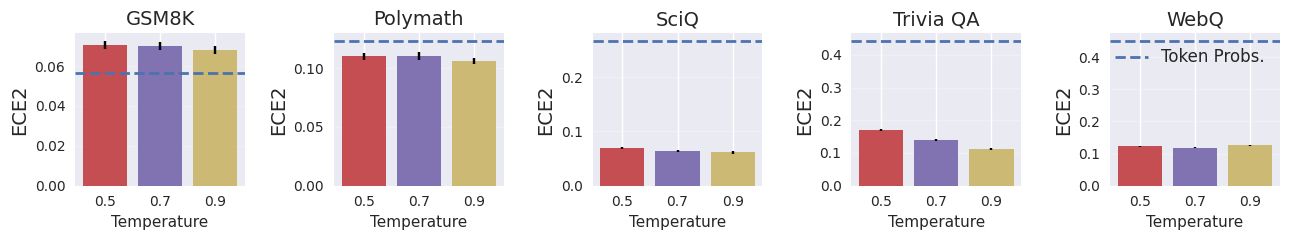

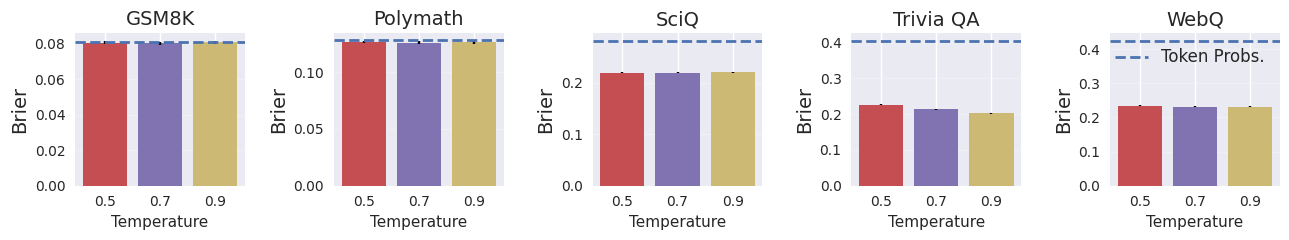

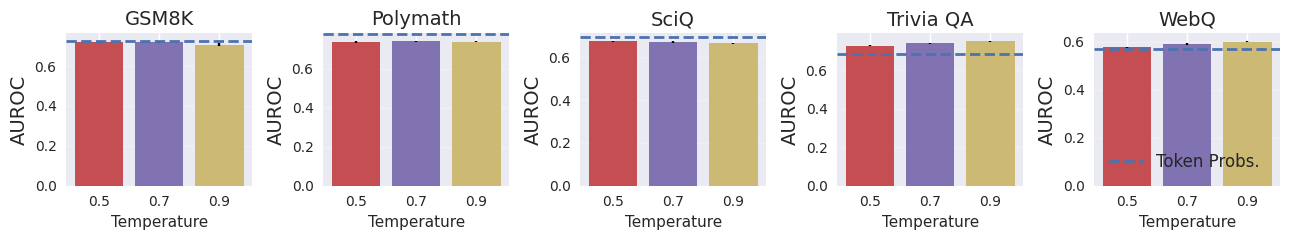

*** DONE ***
*** MODEL: Qwen/Qwen3-4B-Thinking-2507 ***
AVERAGE


,temp_train,ECE1,ECE2,Brier,AUROC
0,0.5,0.061985,0.077981,0.152897,0.696265
1,0.7,0.060524,0.075787,0.151177,0.703072
2,0.9,0.061845,0.076845,0.150967,0.704800


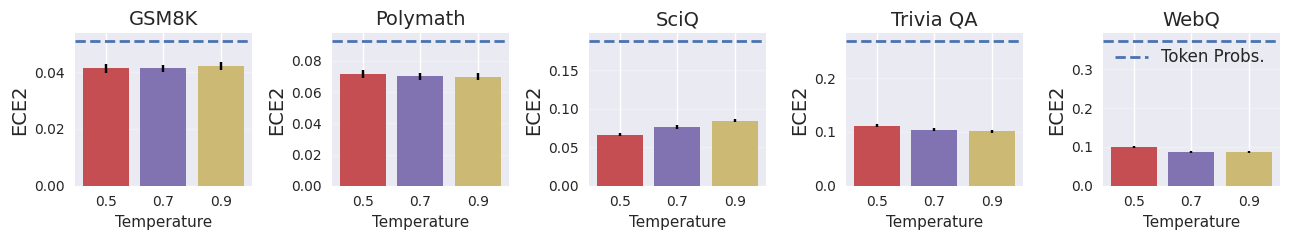

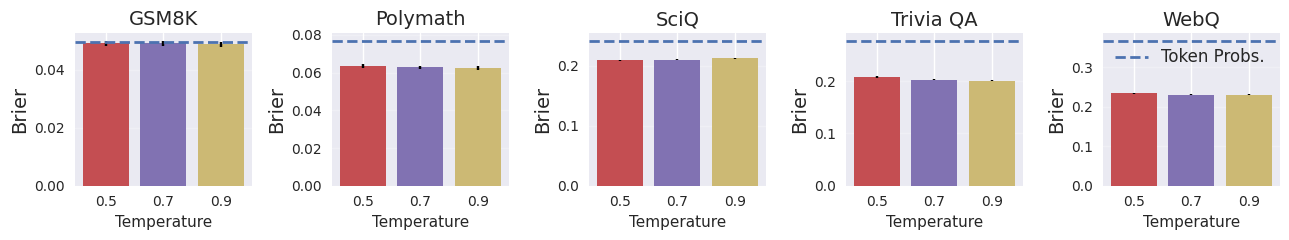

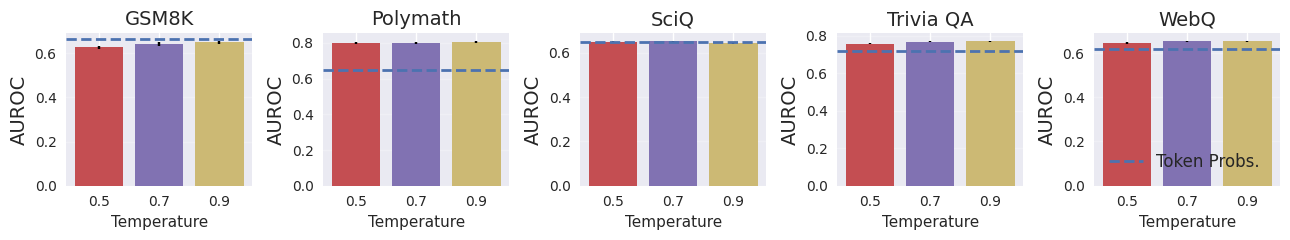

*** DONE ***


In [198]:
for model in models:
    analyze_by_model(model, full_df)